## Homework 2

> [!NOTE]
> This homework uses the pinned 2026 car fuel-efficiency release in the course
> repository. The plan and report are available in `cohorts/2026/data/`.

### Dataset

For this homework, we'll use the 2026 Car Fuel Efficiency dataset. Download it from <a href='https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'>here</a>.

You can do it with wget:
```bash
wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
```

The goal of this homework is to create a regression model for predicting the car fuel efficiency (column `'fuel_efficiency_mpg'`).



### Preparing the dataset 

Use only the following columns:

* `'engine_displacement'`,
* `'horsepower'`,
* `'vehicle_weight'`,
* `'model_year'`,
* `'fuel_efficiency_mpg'`

### EDA

* Look at the `fuel_efficiency_mpg` variable. Does it have a long tail? 


In [98]:
import numpy as np 
import pandas as pd


In [99]:
raw_df = pd.read_csv("car_fuel_efficiency_2026.csv")
df = raw_df.copy()[[
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg']]


<Axes: >

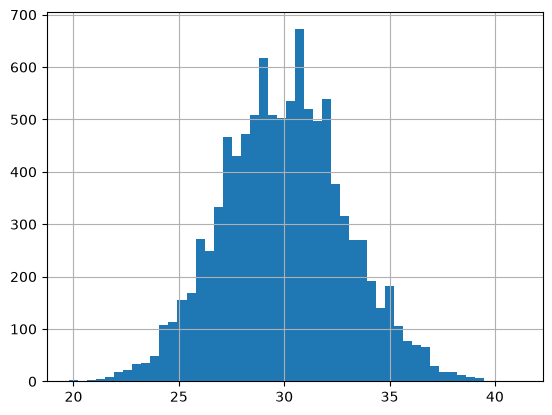

In [100]:
df.fuel_efficiency_mpg.hist(bins=50)

fuel efficiency no long tail


### Question 1

There's one column with missing values. What is it?

* `'engine_displacement'`
* `'horsepower'`
* `'vehicle_weight'`
* `'model_year'`



In [101]:
df.isna().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

Answer: "horsepower"


### Question 2

What's the median (50% percentile) for variable `'horsepower'`?

- 204
- 254
- 304
- 354


In [102]:
df.horsepower.median()

np.float64(254.0)

Answer: 254.0

### Prepare and split the dataset

Shuffle the filtered dataset and create the split exactly as in the lecture:

```python
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]
```

For Q5, repeat the same block with each listed seed. For Q6, use seed `9`.



In [103]:
def split_dataset_train_val_test(df, seed = 42, pct = 0.2):
    n = len(df)
    n_val = int(n*pct)
    n_test = int(n*pct)
    n_train = n-n_val-n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = df.iloc[idx[n_train:n_train+n_val]].reset_index(drop=True)
    df_test= df.iloc[idx[n_train+n_val:]].reset_index(drop=True)

    return df_train, df_val, df_test

class IOData:
    def __init__(self,features, targets):

        self.features = features
        self.targets = targets
        self.X = self.features.to_numpy()
        self.y = self.targets.to_numpy()
        self.Xe = np.column_stack([np.ones(self.X.shape[0]), self.X])

    def __repr__(self):
        return f"Features: {self.features}\nTargets: {self.targets}"
    def to_matrices(self):
       pass 
        

class ModelData:
    def __init__(self, train, val, test):
        self.train = train
        self.val = val
        self.test = test
    

def split_feature_target_columns(
    df, target_columns: list[str], training_columns: list[str] | None = None
):
    if training_columns is None:
        training_columns = [c for c in df.columns if c not in target_columns]

    S = IOData(df[training_columns], df[target_columns])
    return S

datadict = {}
for label,dff in zip(['train','val','test'],split_dataset_train_val_test(df)):
    datadict[label] = split_feature_target_columns(dff,['fuel_efficiency_mpg'])

D = ModelData(**datadict)
D.test.Xe
# , D.val, D.test

array([[1.000e+00, 2.370e+03, 2.680e+02, 4.410e+03, 1.981e+03],
       [1.000e+00, 2.240e+03, 2.560e+02, 4.220e+03, 2.020e+03],
       [1.000e+00, 2.090e+03, 2.170e+02, 3.910e+03, 2.023e+03],
       ...,
       [1.000e+00, 2.430e+03, 2.460e+02, 4.660e+03, 2.013e+03],
       [1.000e+00, 2.450e+03, 3.070e+02, 4.500e+03, 2.014e+03],
       [1.000e+00, 2.060e+03, 2.730e+02, 3.960e+03, 1.997e+03]],
      shape=(2000, 5))


### Question 3

* We need to deal with missing values for the column from Q1.
* We have two options: fill it with 0 or with the mean of this variable.
* Try both options. For each, train a linear regression model without regularization using the code from the lessons.
* For computing the mean, use the training only!
* Use the validation dataset to evaluate the models and compare the RMSE of each option.
* Round the RMSE scores to 3 decimal digits using `round(score, 3)`. This
  keeps the imputation difference visible in this release.
* Which option gives better RMSE?

Options:

- With 0
- With mean
- Both are equally good



In [104]:
for name, data in vars(D).items():
    print(name)

train
val
test


In [ ]:
import logging

logging.basicConfig(
    level=logging.DEBUG,
    format="%(asctime)s | %(levelname)s | %(message)s",
    force=True
)

logger = logging.getLogger(__name__)


In [123]:

def fill_nan_values_of_model_data(D:ModelData, features_dict:dict={},target_dict:dict={}):

    for section, data in vars(D).items():
        data.features = data.features.fillna(features_dict)
        data.targets = data.targets.fillna(target_dict)
        data.X = data.features.to_numpy()
        data.y = data.targets.to_numpy()
        data.Xe = np.column_stack([np.ones(data.X.shape[0]), data.X])
    

fill_nan_values_of_model_data(D,features_dict={'horsepower':0})


In [124]:
# A = df.copy()
# A.loc[12:34,'model_year'] = np.nan
# A = A.fillna({
#     # 'horsepower':123,
#     'model_year':np.random.randint(2000,2026)
# })
# pd.isna(A).any()

In [129]:

def train_linear_regression(X,y, put_ones = False):
    if put_ones:
        ones = np.ones(X.shape[0])
        X = np.column_stack([ones, X])
    # XTX = X.T.dot(X)
    # XTX_inv = np.linalg.inv(XTX)
    # w_full = XTX_inv.dot(X.T).dot(y)
    # return w_full

    # logger.debug(f"\nX:\n{X},\ny:\n{y}")
    if np.isnan(X).any(): # True se contiene NaN
        raise Exception("X contains NaN values")
        return  
    XTX = X.T@X
    # logger.debug(f"\nX.T:\n{X.T}")
    # logger.debug(f"\nXTX:\n{XTX}")
    XTX_inv = np.linalg.inv(XTX)
    # logger.debug(f"\nXTX_inv:\n{XTX_inv}")
    # logger.debug(f"\nXTX_inv shape:\n{XTX_inv.shape}")

    w = XTX_inv @ X.T @ y
    return w



w = train_linear_regression(D.train.Xe,D.train.y)

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: ylabel='Density'>

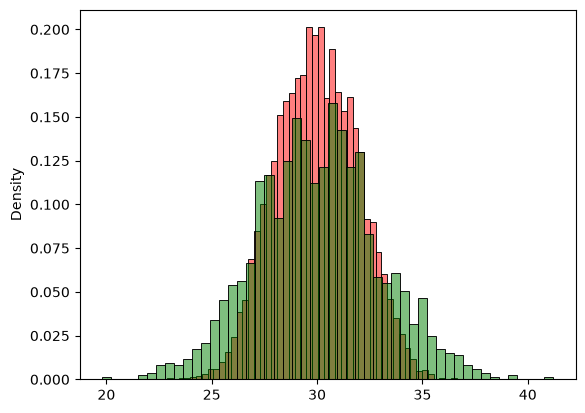

In [142]:
y_pred = w[0] + D.train.X.dot(w[1:]).ravel()
y_train = D.train.y.ravel()
y_val = D.val.y.ravel()

sns.histplot(y_pred, color='red', alpha=0.5, bins=50, stat="density")
# sns.histplot(y_train, color='blue', alpha=0.5, bins=50, stat="density")
sns.histplot(y_val, color='green', alpha=0.5, bins=50, stat="density")




### Question 4

* Now let's train a regularized linear regression.
* For this question, fill the NAs with 0. 
* Try different values of `r` from this list: `[0, 0.01, 0.1, 1, 5, 10, 100]`.
* Use RMSE to evaluate the model on the validation dataset.
* Round the RMSE scores to 4 decimal digits. This keeps the small but real
  regularization differences visible instead of turning several choices into a tie.
* Which `r` gives the best RMSE?

If multiple options give the same best RMSE, select the smallest `r`.

Options:

- 0
- 0.01
- 0.1
- 1
- 5
- 10
- 100


### Question 5 

* We used seed 42 for splitting the data. Let's find out how selecting the seed influences our score.
* Try different seed values: `[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]`.
* For each seed, do the train/validation/test split with 60%/20%/20% distribution.
* Fill the missing values with 0 and train a model without regularization.
* For each seed, evaluate the model on the validation dataset and collect the RMSE scores. 
* What's the standard deviation of all the scores? To compute the standard deviation, use `np.std`.
* Round the result to 3 decimal digits (`round(std, 3)`)

What's the value of std?

- 0.006
- 0.016
- 0.029
- 0.036

> Note: Standard deviation shows how different the values are.
> If it's low, then all values are approximately the same.
> If it's high, the values are different. 
> If standard deviation of scores is low, then our model is *stable*.


### Question 6

* Split the dataset like previously, use seed 9.
* Combine train and validation datasets.
* Fill the missing values with 0 and train a model with `r=0.001`. 
* What's the RMSE on the test dataset?

Options:

- 0.236
- 2.236
- 22.10
- 221.0

## Submit the results

* Submit your results here: https://courses.datatalks.club/ml-zoomcamp-2026/homework/hw02
* The numerical options are calculated from the pinned 2026 release. Use the value that matches your calculation; do not choose a merely close value.